In [1]:
!pip install opencv-python-headless

In [2]:
import cv2
import numpy as np
from google.colab import files
from datetime import datetime
import os
from google.colab.patches import cv2_imshow

In [3]:
os.makedirs("screenshots", exist_ok=True)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
print("Setup complete ✅")

Setup complete ✅


In [4]:
def process_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        status = "⚠️ No face detected"
    elif len(faces) == 1:
        status = "✅ Normal"
    else:
        status = "🚨 Multiple faces detected"
    print("Faces detected:", len(faces))
    print("Status:", status)
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    if len(faces) != 1:
        filename = f"screenshots/alert_{datetime.now().strftime('%H%M%S')}.jpg"
        cv2.imwrite(filename, img)
        print("Screenshot saved:", filename)
    cv2_imshow(img)

Saving WhatsApp Image 2026-01-23 at 5.02.29 PM.jpeg to WhatsApp Image 2026-01-23 at 5.02.29 PM.jpeg
Faces detected: 1
Status: ✅ Normal


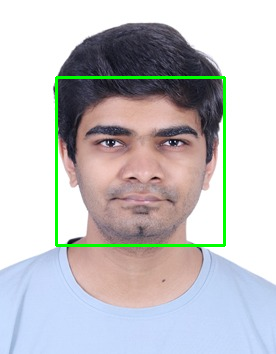

In [7]:
uploaded = files.upload()
for filename in uploaded.keys():
    process_image(filename)

<IPython.core.display.Javascript object>

Faces detected: 0
Status: ⚠️ No face detected
Screenshot saved: screenshots/alert_143435.jpg


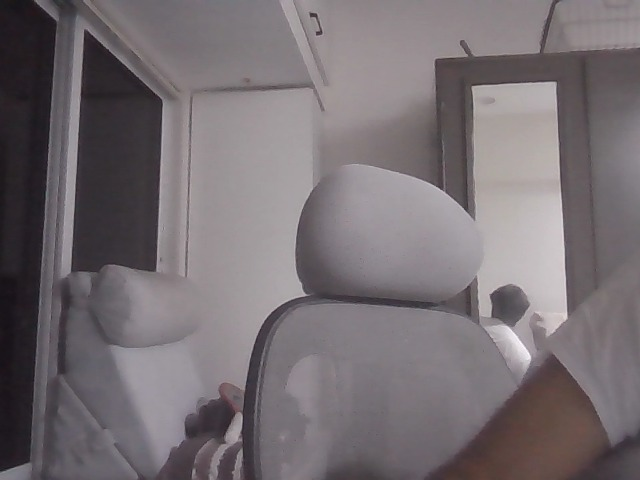

In [10]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
def take_photo(filename='photo.jpg'):
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();
      document.body.appendChild(div);
      div.appendChild(video);
      await new Promise((resolve) => capture.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg');
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename
photo = take_photo()
process_image(photo)

In [12]:
!pip install opencv-python-headless

In [13]:
import cv2
import os
from datetime import datetime
from google.colab.patches import cv2_imshow

In [14]:
os.makedirs("screenshots", exist_ok=True)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

In [15]:
def process_frame(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    status = "Normal"
    color = (0, 255, 0)
    if len(faces) == 0:
        status = "ALERT: No Face"
        color = (0, 0, 255)
    elif len(faces) > 1:
        status = "ALERT: Multiple Faces"
        color = (0, 0, 255)
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
    cv2.putText(img, status, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    if len(faces) != 1:
        filename = f"screenshots/alert_{datetime.now().strftime('%H%M%S')}.jpg"
        cv2.imwrite(filename, img)
    cv2_imshow(img)
    print("Faces:", len(faces), "| Status:", status)

In [16]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
def take_photo(filename='photo.jpg'):
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const button = document.createElement('button');
      button.textContent = 'Capture';
      div.appendChild(button);
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();
      document.body.appendChild(div);
      div.appendChild(video);
      await new Promise((resolve) => button.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg');
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

<IPython.core.display.Javascript object>

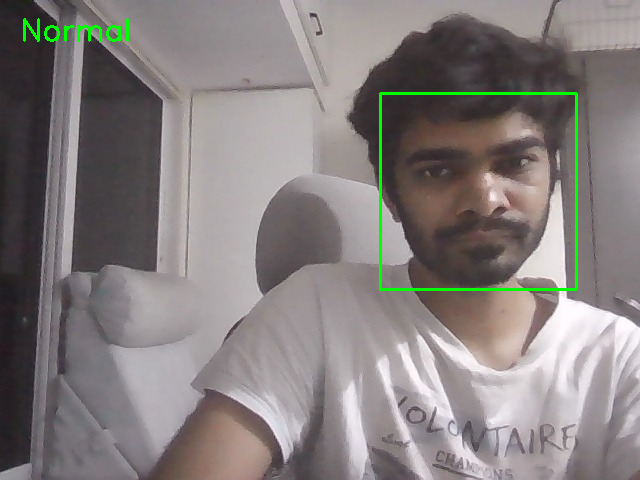

Faces: 1 | Status: Normal
Continue? (y/n): y


<IPython.core.display.Javascript object>

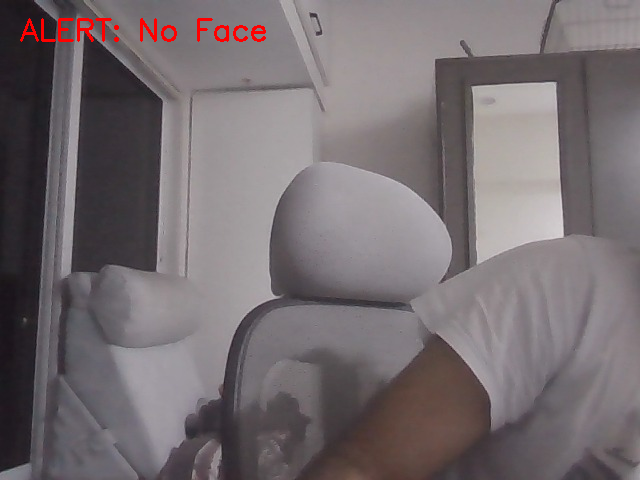

Faces: 0 | Status: ALERT: No Face
Continue? (y/n): n


In [19]:
while True:
    img_path = take_photo()
    frame = cv2.imread(img_path)
    process_frame(frame)
    cont = input("Continue? (y/n): ")
    if cont.lower() != 'y':
        break